In [2]:
import pandas as pd
import seaborn as sns
from tcrdist.repertoire import TCRrep
from tcrdist.adpt_funcs import import_adaptive_file, adaptive_to_imgt
import re
import numpy as np
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import matplotlib as mpl
from itertools import combinations_with_replacement, combinations
from umap import UMAP
from scipy.stats import gaussian_kde

mpl.rcParams.update({'font.size': 8, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8 
mpl.rcParams['ytick.labelsize'] = 8


/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [3]:
DATA_PATH = "Your Path Here to AllClones_all_extra.csv"
CLUSER_PATH = "Your Path here to Clustered_and_filtered.csv"

all_data = pd.read_csv("/Users/pressm/Documents/AziziLab/GVHD/immunoseq_r/AllClones_all_extra.csv", low_memory=False) #Downlaod from Google Drive
clustered_data = pd.read_csv("../input_data/Clustered_and_filtered.csv")
clustered_data = clustered_data.drop("Unnamed: 0", axis = 1)

# Filter & Process Data

In [4]:
df = all_data.copy()
df = df[df["timepoint"].apply(lambda x: x.isnumeric())]
df = df[df["templates"] > 0]
df = df[df['type'] == "allo"]
df['timepoint'] = df['timepoint'].astype(int)
df = df[df["timepoint"]<365]

#Combined with data learned from basis
df = df.merge(clustered_data, how = "right", on = ["cdr3_amino_acid", "PatientID"],)

In [5]:
#Change column names to match 'subject', 'productive_frequency', 'templates', 'epitope', 'cdr3_b_aa','v_b_gene', 'j_b_gene', 'valid_cdr3', 'cdr3_b_nucseq' where appropriate
df["subject"] = df["PatientID"]
df["productive_frequency"] = df["frequency"]
df["count"] = df["templates"]
df["cdr3_b_aa"] = df["cdr3_amino_acid"]
df["cdr3_b_nucseq"] = df["cdr3_rearrangement"]
df["v_b_gene"] = df["v_resolved"]
df["j_b_gene"] = df["j_resolved"]
df["valid_cdr3"] = True

df = df[['subject', 'productive_frequency', 'count', 'cdr3_b_aa','v_b_gene', 'j_b_gene', 'valid_cdr3', 'cdr3_b_nucseq', 'timepoint', "GVHD_GRADE_1", "variable"]]

In [6]:

#Convert Addaptive V and J gene to IMGT
#First add a 0 to the single digit number after TRBV or TRBJ

df['v_b_gene'] = df['v_b_gene'].str.replace(r'(TRBV)(\d)(?!\d)', r'\g<1>0\2', regex=True)
df['j_b_gene'] = df['j_b_gene'].str.replace(r'(TRBJ)(\d)(?!\d)', r'\g<1>0\2', regex=True)

df['v_b_gene'] = df['v_b_gene'].str.replace(r'-(\d)(?!\d)', r'-0\1', regex=True)
df['j_b_gene'] = df['j_b_gene'].str.replace(r'-(\d)(?!\d)', r'-0\1', regex=True)

df['v_b_gene'] = df['v_b_gene'].str.replace(r'^T', 'TC', regex=True)
df['j_b_gene'] = df['j_b_gene'].str.replace(r'^T', 'TC', regex=True)

df['v_b_gene'] = df['v_b_gene'].str.replace(' ', '', regex=False)
df['j_b_gene'] = df['j_b_gene'].str.replace(' ', '', regex=False)

df['v_b_gene'] = df['v_b_gene'].apply(lambda x: adaptive_to_imgt['human'].get(x, "NA"))
df['j_b_gene'] = df['j_b_gene'].apply(lambda x: adaptive_to_imgt['human'].get(x, "NA"))

In [7]:
#Remove any clones where V and J Genes aren't mapped
df_test = df.copy()
df_test = df_test.dropna(subset = ["cdr3_b_aa", "cdr3_b_nucseq"])
df_test = df_test[df_test["v_b_gene"] != "NA"]
df_test = df_test[df_test["j_b_gene"] != "NA"]
df_test = df_test.reset_index(drop = True)


In [8]:
#Drop any duplicates since we only want to count each clone once.
df_no = pd.concat([df_test[df["variable"] == 4], df_test[df["variable"] == 8]]).drop_duplicates(subset = ["cdr3_b_aa", "v_b_gene", "j_b_gene", "cdr3_b_nucseq", "subject"])
df_no = df_no[df_no["GVHD_GRADE_1"] == "No"].reset_index(drop = True)

df_mild = df_test[df["variable"] == 1].reset_index(drop = True).drop_duplicates(subset = ["cdr3_b_aa", "v_b_gene", "j_b_gene", "cdr3_b_nucseq", "subject"])
df_mild = df_mild[df_mild["GVHD_GRADE_1"] == "Mild"].reset_index(drop = True)

df_severe =  pd.concat([df_test[df["variable"] == 2], df_test[df["variable"] == 7],df_test[df["variable"] == 9]]).drop_duplicates(subset = ["cdr3_b_aa", "v_b_gene", "j_b_gene", "cdr3_b_nucseq", "subject"]).reset_index(drop = True)
df_severe = df_severe[df_severe["GVHD_GRADE_1"] == "Severe"]

df_all_grades = pd.concat([df_no, df_mild, df_severe])
df_all_grades = df_all_grades[df_all_grades["v_b_gene"] != "NA"]
df_all_grades = df_all_grades[df_all_grades["j_b_gene"] != "NA"]

df_all_grades.drop(["productive_frequency", "count", "timepoint", "variable"], axis = 1, inplace = True)
df_all_grades = df_all_grades.reset_index(drop = True)

/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_21793/4018277024.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_no = pd.concat([df_test[df["variable"] == 4], df_test[df["variable"] == 8]]).drop_duplicates(subset = ["cdr3_b_aa", "v_b_gene", "j_b_gene", "cdr3_b_nucseq", "subject"])
/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_21793/4018277024.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_no = pd.concat([df_test[df["variable"] == 4], df_test[df["variable"] == 8]]).drop_duplicates(subset = ["cdr3_b_aa", "v_b_gene", "j_b_gene", "cdr3_b_nucseq", "subject"])
/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_21793/4018277024.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mild = df_test[df["variable"] == 1].reset_index(drop = True).drop_duplicates(subset = ["cdr3_b_aa", "v_b_gene", "j_b_gene", "cdr3_b_nucseq", "subject"])
/var/folders/gx/mj33

# Calculate TCRDist Between CDR3 Sequences

In [9]:

tr = TCRrep(cell_df = df_all_grades, 
            organism = 'human', 
            chains = ['beta'],
            cpus = 1, 
            db_file = 'alphabeta_gammadelta_db.tsv', compute_distances = False)

tr.compute_distances()

/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/tcrdist/repertoire.py:159: UserWarning: cell_df needs a counts column to track clonal number of frequency

  self._validate_cell_df()
/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/tcrdist/repertoire.py:791: UserWarning: No 'count' column provided; count column set to 1
  warnings.warn("No 'count' column provided; count column set to 1")


/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


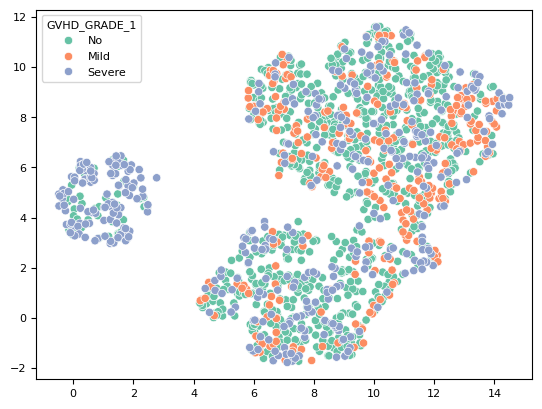

In [10]:

umap = UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.5)
umap_results = umap.fit_transform(tr.pw_beta)

#Plot Umap results
sns.scatterplot(x=umap_results[:,0], y=umap_results[:,1], hue=df_all_grades["GVHD_GRADE_1"], palette = "Set2")
plt.show()

In [11]:
df_all_grades["GVHD_GRADE_Mod"] = df_all_grades["GVHD_GRADE_1"].apply(lambda x: "No/Mild" if x in ("No", "Mild") else x)

In [14]:
# Get distances between classes of GVHD
groups = ['No', 'Mild', 'Severe']
for g1, g2 in combinations_with_replacement(groups, 2):
    col_name = f"{g1}_{g2}"
    df_all_grades[col_name] = np.nan
    rows_g1 = np.where(df_all_grades["GVHD_GRADE_1"] == g1)[0]
    rows_g2 = np.where(df_all_grades["GVHD_GRADE_1"] == g2)[0]

    for i in rows_g1:
        df_all_grades.loc[df_all_grades.index[i], col_name] = tr.pw_beta[i, rows_g2].mean()
    for i in rows_g2:
        df_all_grades.loc[df_all_grades.index[i], col_name] = tr.pw_beta[i, rows_g1].mean()
        
        
# Get distances between classes of GVHD
groups_2 = ['No/Mild', 'Severe']
for g1, g2 in combinations_with_replacement(groups_2, 2):
    col_name = f"{g1}_{g2}"
    df_all_grades[col_name] = np.nan
    rows_g1 = np.where(df_all_grades["GVHD_GRADE_Mod"] == g1)[0]
    rows_g2 = np.where(df_all_grades["GVHD_GRADE_Mod"] == g2)[0]

    for i in rows_g1:
        df_all_grades.loc[df_all_grades.index[i], col_name] = tr.pw_beta[i, rows_g2].mean()
    for i in rows_g2:
        df_all_grades.loc[df_all_grades.index[i], col_name] = tr.pw_beta[i, rows_g1].mean()

# Plot Results

In [ ]:
#Mean of each comparison
print("Mean distance between No and Mild: ", df_all_grades["No_Mild"].mean())
print("Mean distance between No and Severe: ", df_all_grades["No_Severe"].mean())
print("Mean distance between Mild and Severe: ", df_all_grades["Mild_Severe"].mean())

#Mean of each comparison
print("Median distance between No and Mild: ", df_all_grades["No_Mild"].median())
print("Median distance between No and Severe: ", df_all_grades["No_Severe"].median())
print("Median distance between Mild and Severe: ", df_all_grades["Mild_Severe"].median())

Mean distance between No and Mild:  146.16963769473196
Mean distance between No and Severe:  148.19343958106796
Mean distance between Mild and Severe:  150.6380875461666
Median distance between No and Mild:  143.4341637010676
Median distance between No and Severe:  146.29550827423168
Median distance between Mild and Severe:  147.75622775800713


/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_21793/1147722520.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

No/Mild vs No/Mild vs. Severe vs Severe: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:3.929e-03 U_stat=2.212e+05
Severe vs Severe vs. No/Mild vs Severe: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:3.977e-05 U_stat=2.904e+05
No/Mild vs No/Mild vs. No/Mild vs Severe: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:5.636e-23 U_stat=7.102e+05


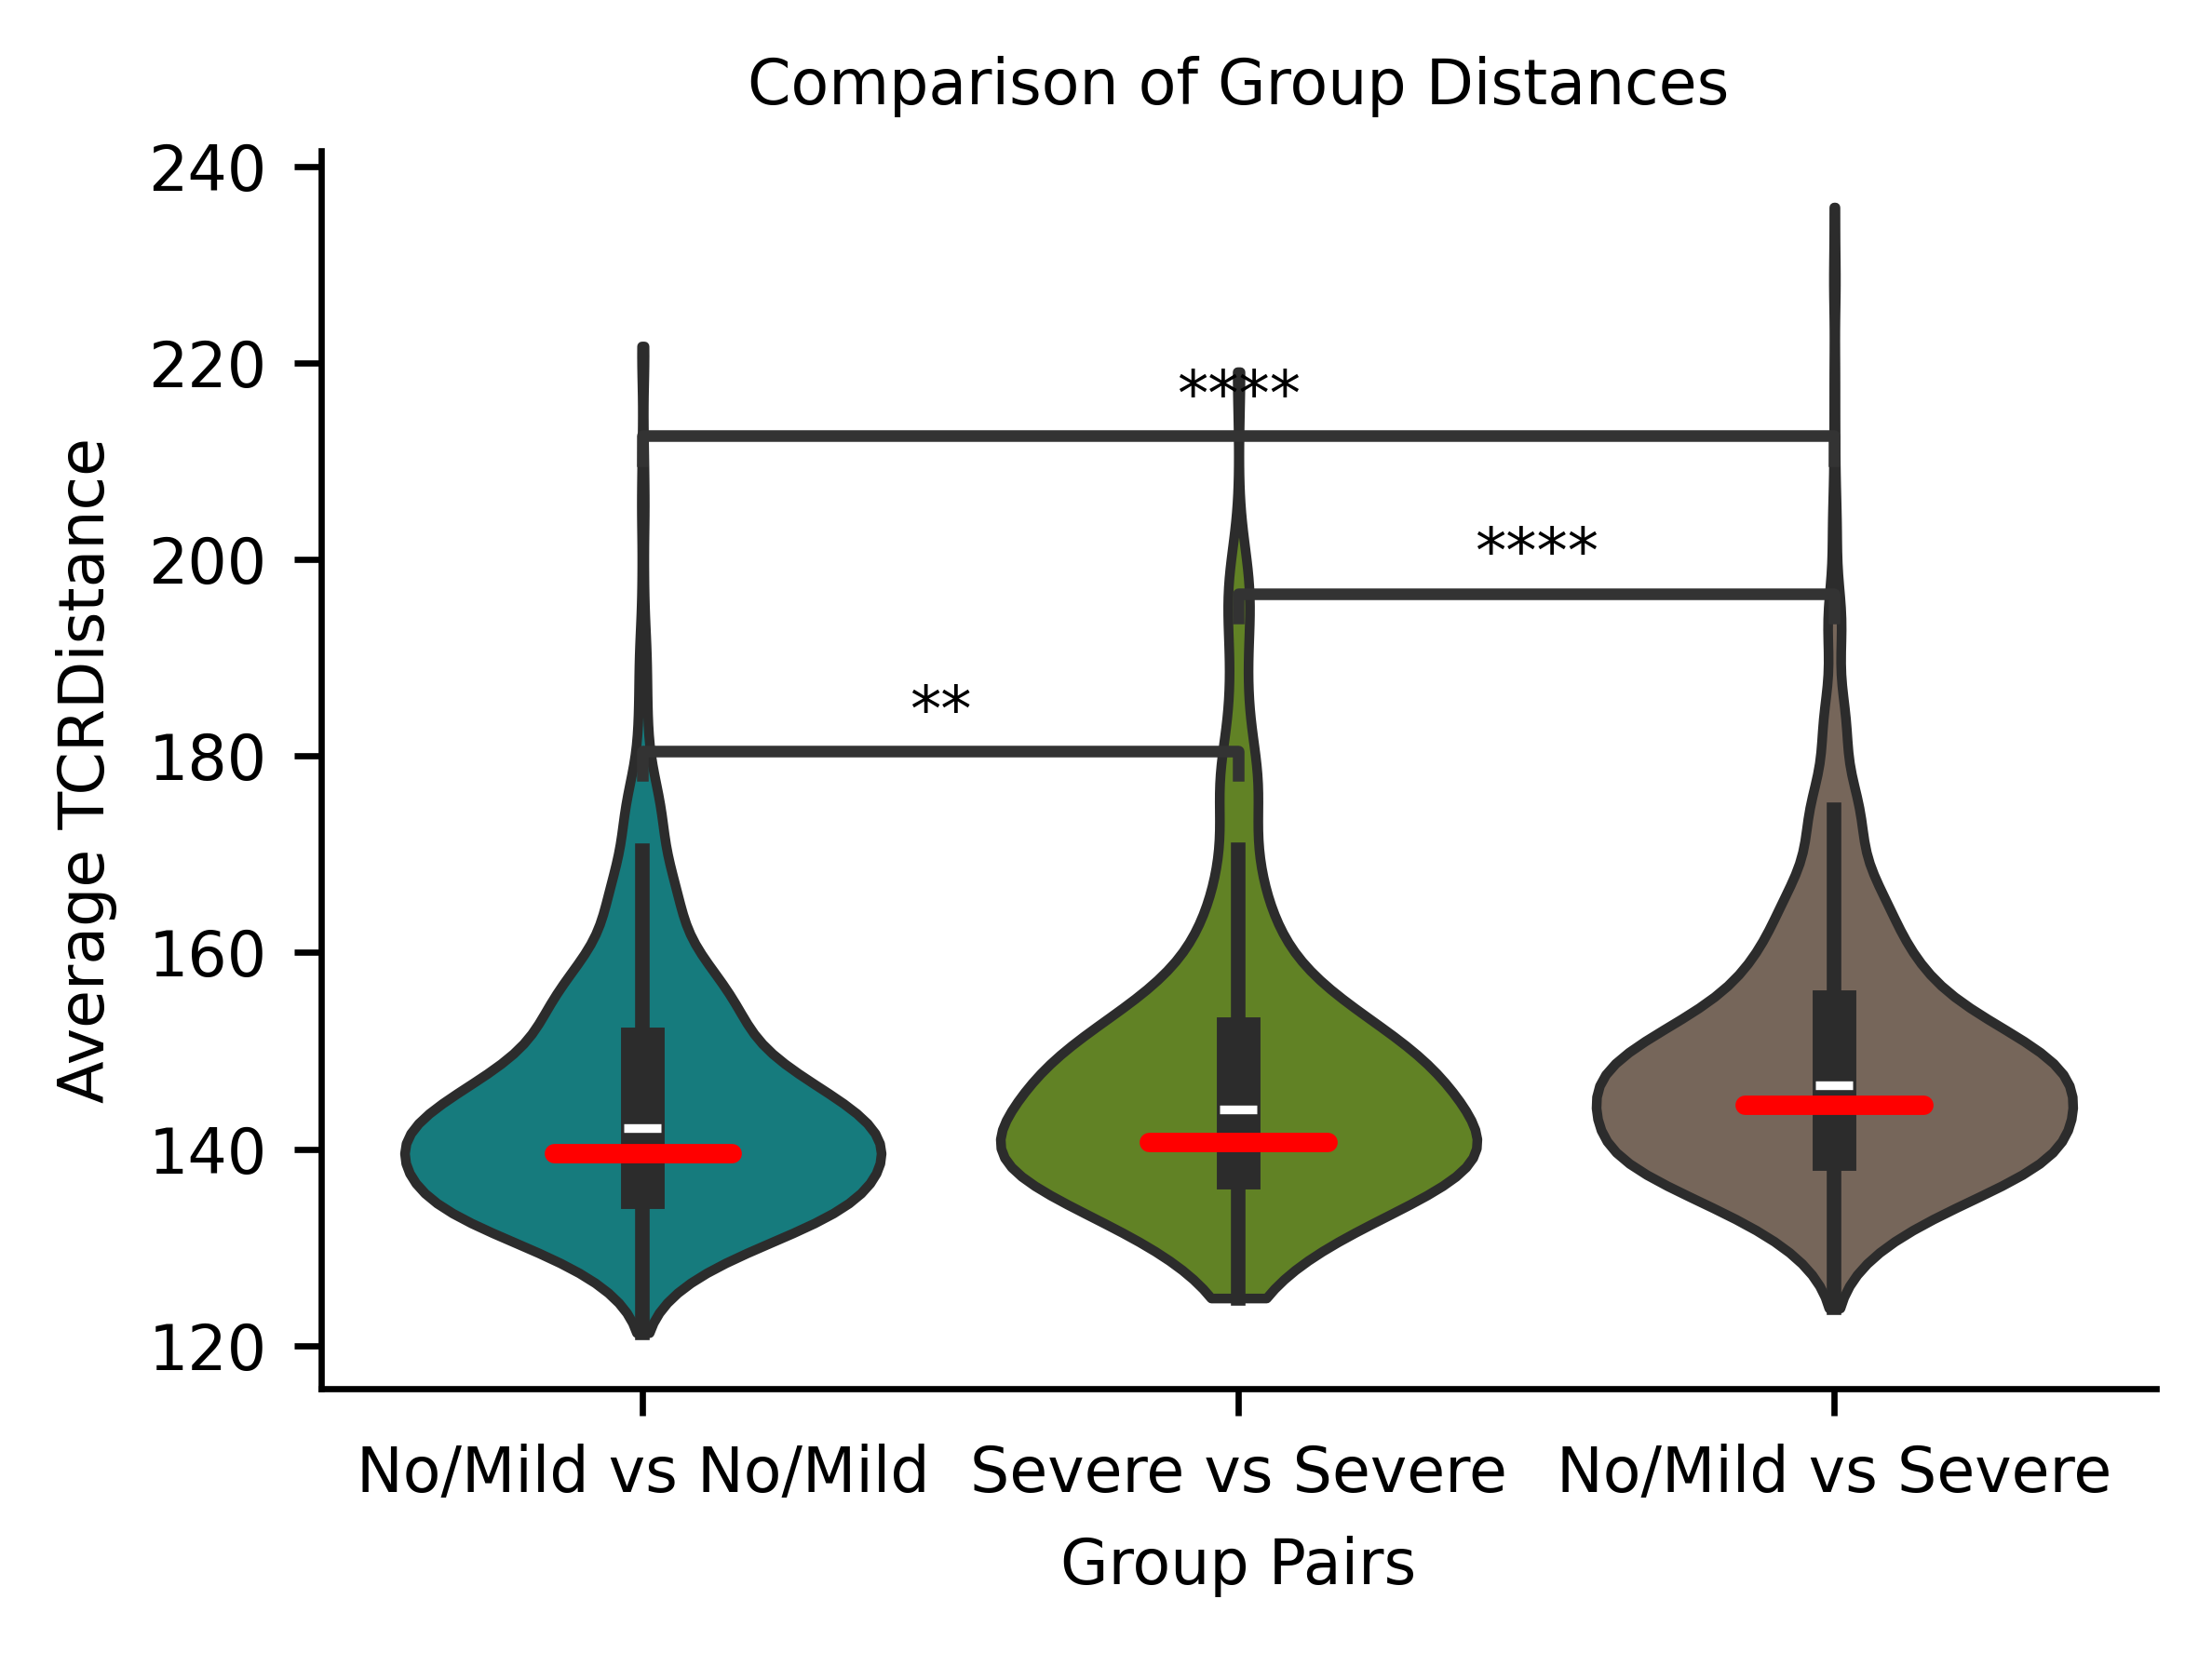

In [30]:
# 1. Reshape Data for Plotting (Wide to Long)
dist_cols = [f"{g1}_{g2}" for g1, g2 in combinations_with_replacement(groups_2, 2)]

df_plot = df_all_grades[dist_cols].melt(
    var_name="Comparison", 
    value_name="Distance"
).dropna()

df_plot["Comparison"] = df_plot["Comparison"].str.replace("_", " vs ")

# Color palette
palette = {
    "No/Mild vs No/Mild": "#058B8E",
    "Severe vs Severe":   "#659116",
    "No/Mild vs Severe":  "#7B6555"
}
order = ["No/Mild vs No/Mild", "Severe vs Severe", "No/Mild vs Severe"]

# 2. Initialize the Plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=600)
sns.violinplot(
    data=df_plot,
    x="Comparison",
    y="Distance",
    order=order,
    inner="box",        # keep the internal boxplot
    palette=palette,
    cut=0,
    ax=ax
)
sns.despine()

# 3. Overlay red crossbar at KDE mode for each group
for i, group in enumerate(order):
    vals = df_plot.loc[df_plot["Comparison"] == group, "Distance"].dropna().values
    kde = gaussian_kde(vals)
    x_grid = np.linspace(vals.min(), vals.max(), 2000)
    mode_val = x_grid[np.argmax(kde(x_grid))]
    ax.plot([i - 0.15, i + 0.15], [mode_val, mode_val],
            color="red", linewidth=2.5, solid_capstyle="round", zorder=5)



# 5. Configure Statistical Annotations
pairs = list(combinations(order, 2))
annotator = Annotator(ax, pairs, data=df_plot, x="Comparison", y="Distance", order=order)
annotator.configure(
    test='Mann-Whitney',
    comparisons_correction='holm',
    text_format='star',      # place bars outside/above the violins
    verbose=2,
)

# 6. Compute and Draw Annotations
annotator.apply_and_annotate()

# 7. Final Layout
plt.title("Comparison of Group Distances")
plt.ylabel("Average TCRDistance")
plt.xlabel("Group Pairs")
plt.tight_layout()

plt.savefig("../FigureOutput/Final_Output/TCRdist_violin_plot.svg", format='svg')
plt.savefig("../FigureOutput/Final_Output/TCRdist_violin_plot.pdf", format='pdf')
plt.savefig("../FigureOutput/Final_Output/TCRdist_violin_plot.png", format='png')

plt.show()


/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_21793/942363515.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/statannotations/compat.py:926: UserWarning: cannot find group1 of pair in the group tuples: ('Mild vs Mild',) not in [('No vs No',), ('No vs Mild',), ('No vs Severe',)]
  warnings.warn(msg)
/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/statannotations/compat.py:926: UserWarning: cannot find group1 of pair in the group tuples: ('Mild vs Severe',) not in [('No vs No',), ('No vs Mild',), ('No vs Severe',)]
  warnings.warn(msg)
/opt/anaconda3/envs/tcrdist/lib/python3.9/site-packages/statannotations/compat.py:926: UserWarning: cannot find group1 of pair in the group tuples: ('Severe vs Severe',) not in [('No vs No',), ('No vs Mild',), ('No vs Sever

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

No vs No vs. No vs Mild: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:2.081e-05 U_stat=4.491e+05
No vs Mild vs. No vs Severe: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:3.286e-07 U_stat=6.597e+05
No vs No vs. No vs Severe: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:5.999e-19 U_stat=4.394e+05


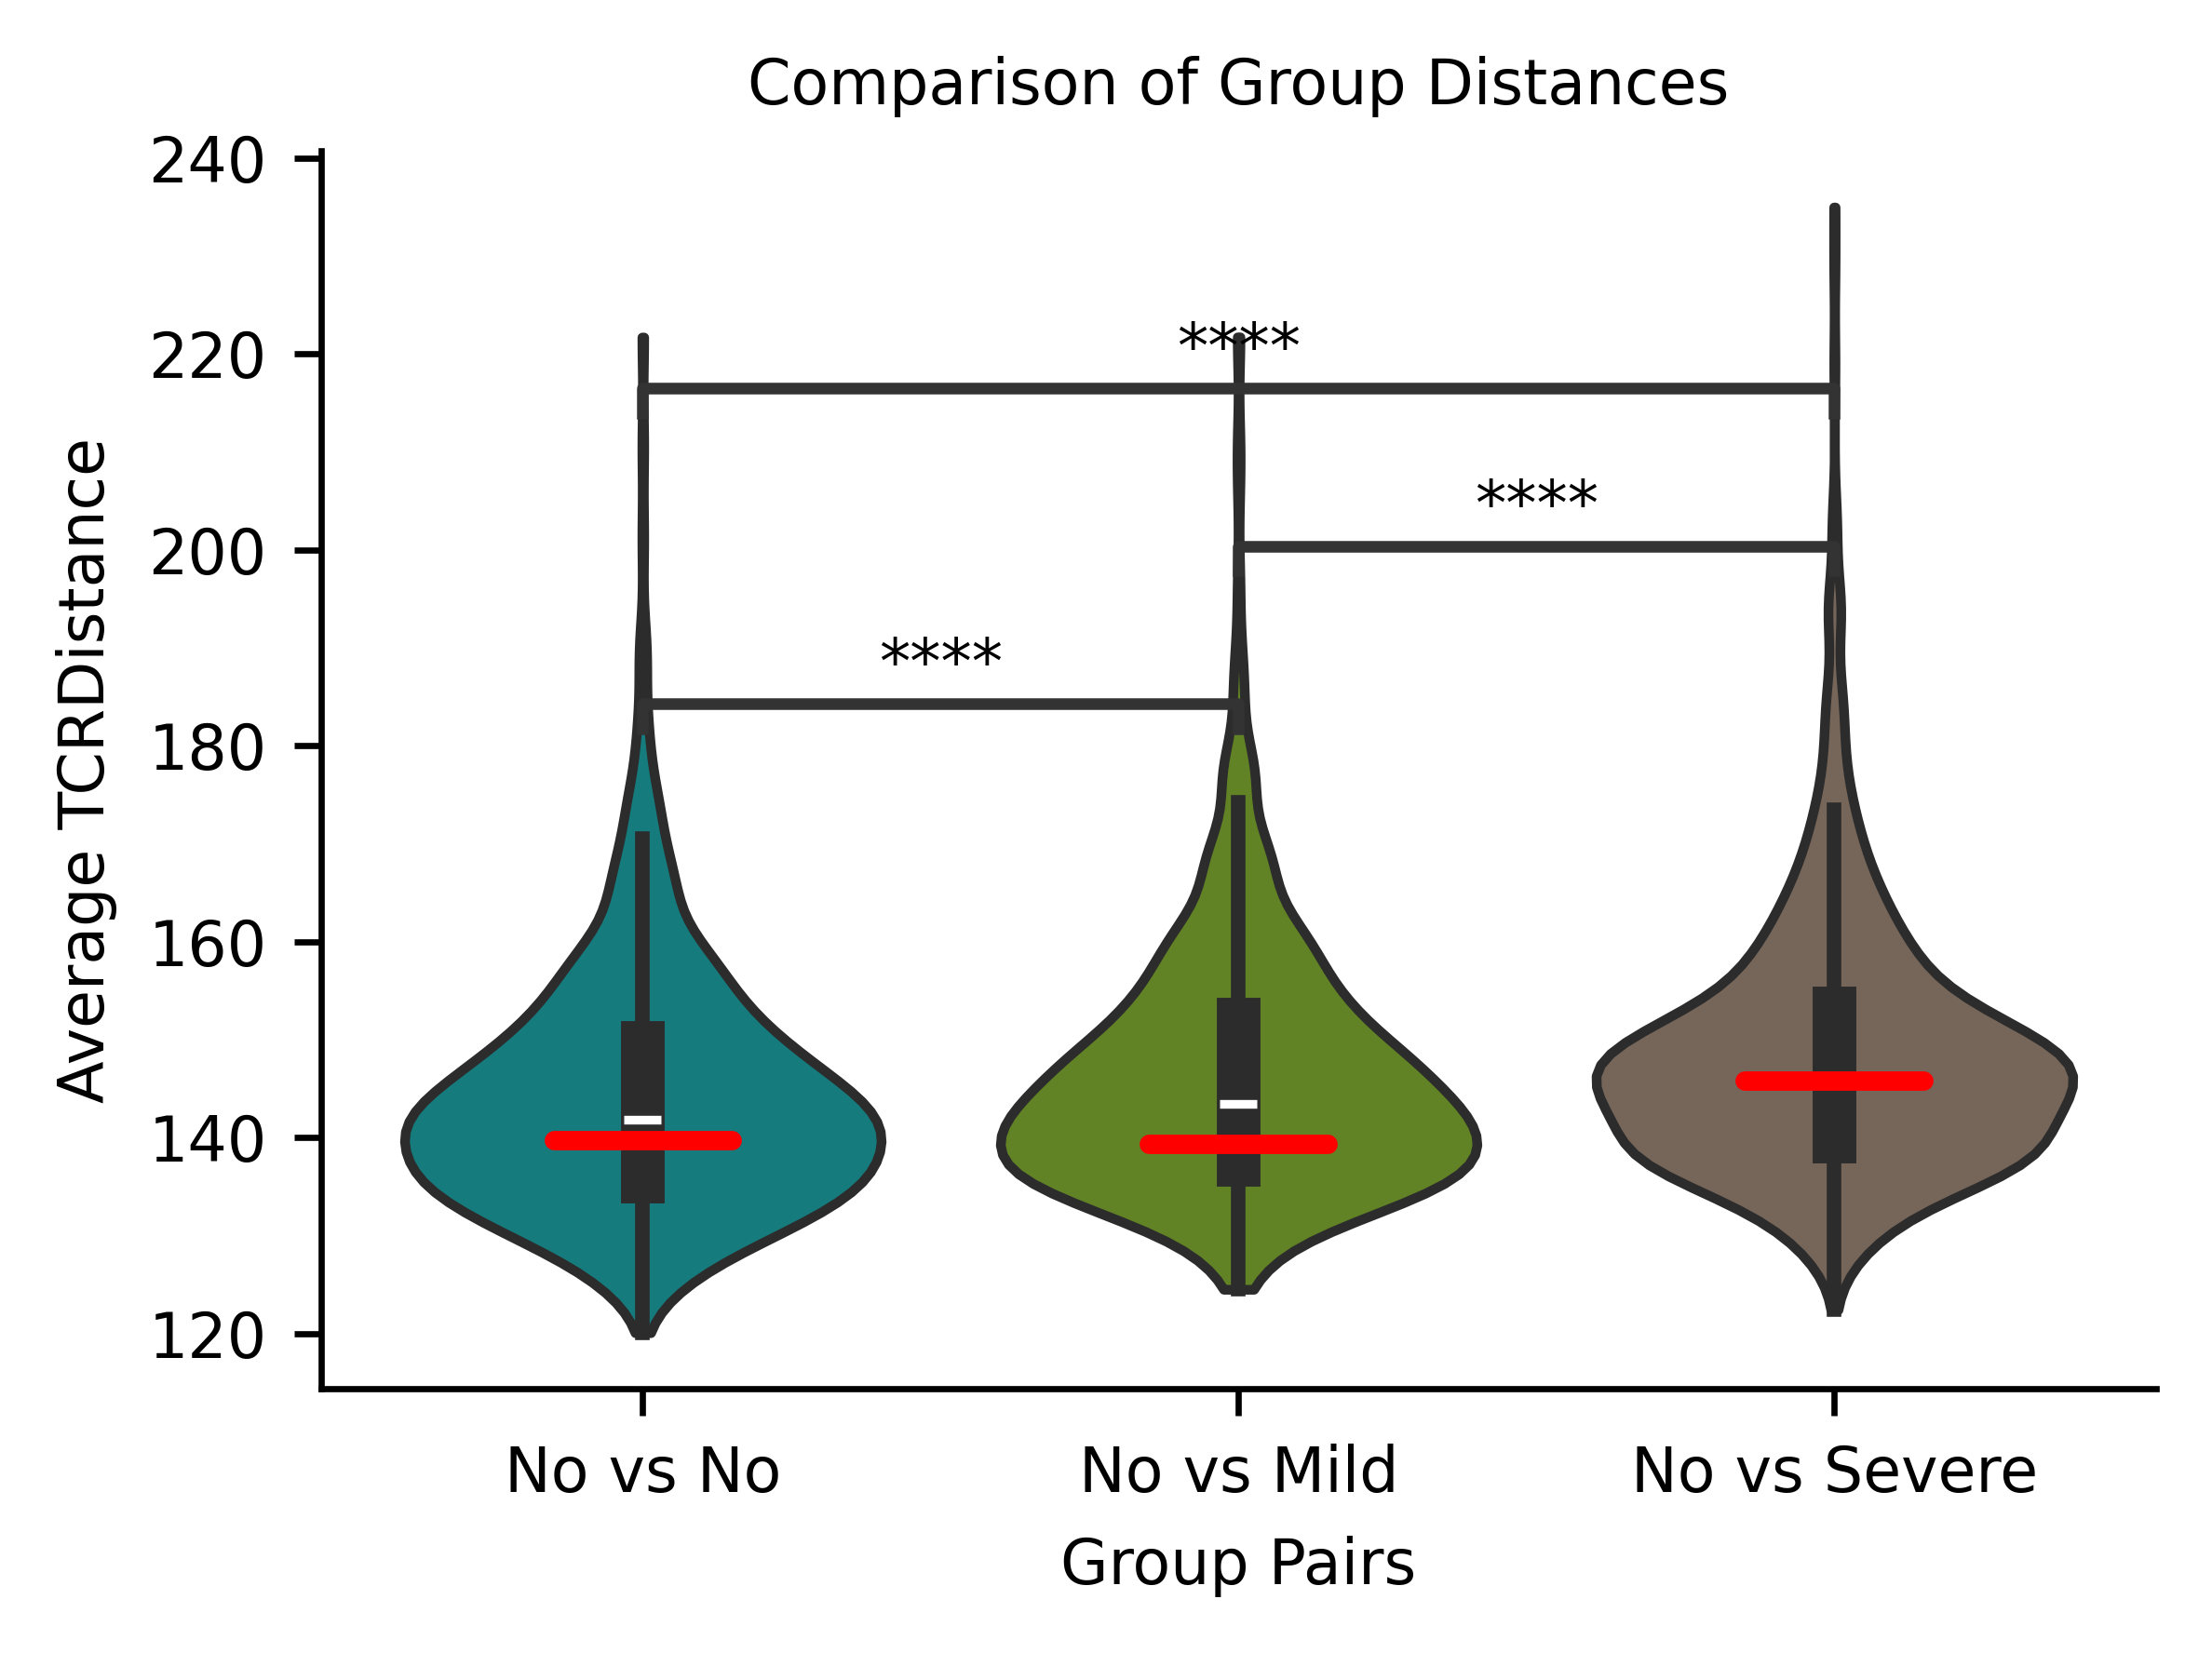

In [31]:
# 1. Reshape Data for Plotting (Wide to Long)
# We select only the columns we created in your loop
dist_cols = [f"{g1}_{g2}" for g1, g2 in combinations_with_replacement(groups, 2)]

# Melt creates a dataframe with two main columns: 'Comparison' (the pair name) and 'Distance' (the value)
df_plot = df_all_grades[dist_cols].melt(
    var_name="Comparison", 
    value_name="Distance"
).dropna() # Remove NaNs so they don't affect plotting/stats

# Clean up label names for better readability (Optional)
df_plot["Comparison"] = df_plot["Comparison"].str.replace("_", " vs ")

# Color palette matching the project color scheme
palette = {
    "No vs No":   "#058B8E",
    "No vs Mild": "#659116",
    "No vs Severe": "#7B6555",
}

# 2. Initialize the Plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=600)
sns.violinplot(
    data=df_plot,
    x="Comparison",
    y="Distance",
    order=["No vs No", "No vs Mild", "No vs Severe"],
    inner="box",
    palette=palette,
    cut=0,
    ax=ax
)
sns.despine()

# 3. Overlay red crossbar at KDE mode for each group
order = ["No vs No", "No vs Mild", "No vs Severe"]
for i, group in enumerate(order):
    vals = df_plot.loc[df_plot["Comparison"] == group, "Distance"].dropna().values
    kde = gaussian_kde(vals)
    x_grid = np.linspace(vals.min(), vals.max(), 2000)
    mode_val = x_grid[np.argmax(kde(x_grid))]
    ax.plot([i - 0.15, i + 0.15], [mode_val, mode_val],
            color="red", linewidth=2.5, solid_capstyle="round", zorder=5)

# 4. Configure Statistical Annotations
# Define the pairs to compare (we compare all unique pairs of the distributions)
unique_comparisons = df_plot["Comparison"].unique()
pairs = list(combinations(unique_comparisons, 2))

annotator = Annotator(ax, pairs, data=df_plot, x="Comparison", y="Distance", order=["No vs No", "No vs Mild", "No vs Severe"])
annotator.configure(
    test='Mann-Whitney',      # This is the Wilcoxon rank-sum test equivalent
    comparisons_correction='holm', 
    text_format='star',       # Displays *, **, *** or 'ns'
    verbose=2,
)

# 5. Compute and Draw Annotations
annotator.apply_and_annotate()

# 6. Final Layout
plt.title("Comparison of Group Distances")
plt.ylabel("Average TCRDistance")
plt.xlabel("Group Pairs")
plt.tight_layout()

plt.savefig("../FigureOutput/Final_Output/TCRdist_violin_plot_all_red.svg", format='svg')
plt.savefig("../FigureOutput/Final_Output/TCRdist_violin_plot_all_red.pdf", format='pdf')
plt.savefig("../FigureOutput/Final_Output/TCRdist_violin_plot_all_red.png", format='png')

plt.show()
